# Week 7 Lab — Consumer and Producer Surplus
**SCIE1500 — Analytical Methods for Scientists (UWA)**

**Lab format:** Work in your groups. Run all code cells in order, fill in the written prompts.

---
**This week:** We use definite integrals to measure welfare — how much buyers and sellers gain from trading at market equilibrium.

---
## 📋 Scientific Scenario

![Supply and demand diagram with consumer and producer surplus](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_7/images/W7_market_welfare.svg?raw=1)

The Australian domestic wheat market has the following supply and demand functions:

- **Demand:** $Q_d = 500 - 4P$ (thousand tonnes per year)
- **Supply:** $Q_s = -100 + 2P$ (thousand tonnes per year)

where $P$ is the price in dollars per tonne.

Consumer surplus (CS) is the area between the demand curve and the equilibrium price — what buyers would have paid minus what they actually pay. Producer surplus (PS) is the area between the equilibrium price and the supply curve.

---
## 🎯 Group Task & Learning Objectives

| Part | Topic | Time |
|------|-------|------|
| A | Find market equilibrium algebraically and verify with Python | ~20 min |
| B | Calculate consumer and producer surplus graphically | ~20 min |
| C | Verify surplus using definite integration | ~20 min |
| D | Verify CS and PS symbolically using SymPy | ~10 min |

By the end you should be able to: solve supply-demand systems algebraically; derive inverse functions; compute CS and PS as definite integrals; interpret welfare measures; and use SymPy (`sp.integrate()`) to evaluate definite integrals symbolically.

In [1]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Demand: Qd = 500 - 4P  →  P = (500 - Q)/4
# Supply: Qs = -100 + 2P →  P = (Q + 100)/2

def demand_P(Q):
    'Inverse demand: price as a function of quantity.'
    return (500 - Q) / 4

def supply_P(Q):
    'Inverse supply: price as a function of quantity.'
    return (Q + 100) / 2

print(f"Demand intercept (P when Q=0): P = {demand_P(0):.0f}")
print(f"Supply intercept (P when Q=0): P = {supply_P(0):.0f}")

Demand intercept (P when Q=0): P = 125
Supply intercept (P when Q=0): P = 50


---
## Part A: Finding Equilibrium (~20 min)

**A.1** Verify the equilibrium algebraically: set $Q_d = Q_s$ and solve for $P^*$, then find $Q^*$.

✏️ Show your working here:
```
Qd = Qs
500 - 4P = -100 + 2P
...
P* = 100, Q* = 100
```

In [2]:
# A.1 — Solve equilibrium numerically (confirm your by-hand algebra)
from numpy.linalg import solve

# At equilibrium Qd = Qs = Q. Rewrite both curves as linear equations in (Q, P):
#   Demand: Qd = 500 - 4P   →   Q + 4P = 500
#   Supply: Qs = -100 + 2P  →   Q - 2P = -100
A = np.array([[1,  4],
              [1, -2]])
b = np.array([500, -100])
Q_eq, P_eq = solve(A, b)

print(f"Equilibrium Price:    P* = ${P_eq:.1f}/tonne")
print(f"Equilibrium Quantity: Q* = {Q_eq:.0f} thousand tonnes")

Equilibrium Price:    P* = $100.0/tonne
Equilibrium Quantity: Q* = 100 thousand tonnes


Plot supply and demand.

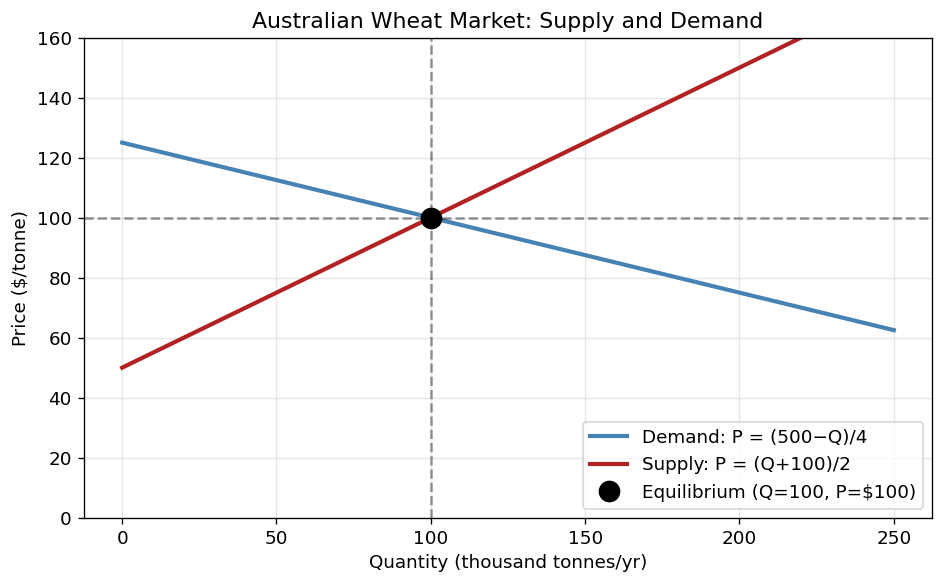

In [3]:
# A.2 — Plot supply and demand
Q_vals = np.linspace(0, 250, 300)
P_demand = demand_P(Q_vals)
P_supply = supply_P(Q_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Q_vals, P_demand, "steelblue", lw=2.5, label="Demand: P = (500−Q)/4")
ax.plot(Q_vals, P_supply, "firebrick", lw=2.5, label="Supply: P = (Q+100)/2")
ax.plot(Q_eq, P_eq, "ko", ms=12, zorder=5, label=f"Equilibrium (Q={Q_eq:.0f}, P=${P_eq:.0f})")
ax.axhline(P_eq, color="k", ls="--", alpha=0.4)
ax.axvline(Q_eq, color="k", ls="--", alpha=0.4)
ax.set_xlabel("Quantity (thousand tonnes/yr)")
ax.set_ylabel("Price ($/tonne)")
ax.set_title("Australian Wheat Market: Supply and Demand")
ax.legend()
ax.set_ylim(0, 160)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part B: Surplus — Graphical (~20 min)

**CS** is the triangle above $P^*$ and below the demand curve:
$$CS = \frac{1}{2} \times Q^* \times (P_{max} - P^*) = \frac{1}{2} \times 100 \times (125 - 100) = 1{,}250 \text{ (\$000)}$$

**PS** is the triangle below $P^*$ and above the supply curve:
$$PS = \frac{1}{2} \times Q^* \times (P^* - P_{min}) = \frac{1}{2} \times 100 \times (100 - 50) = 2{,}500 \text{ (\$000)}$$

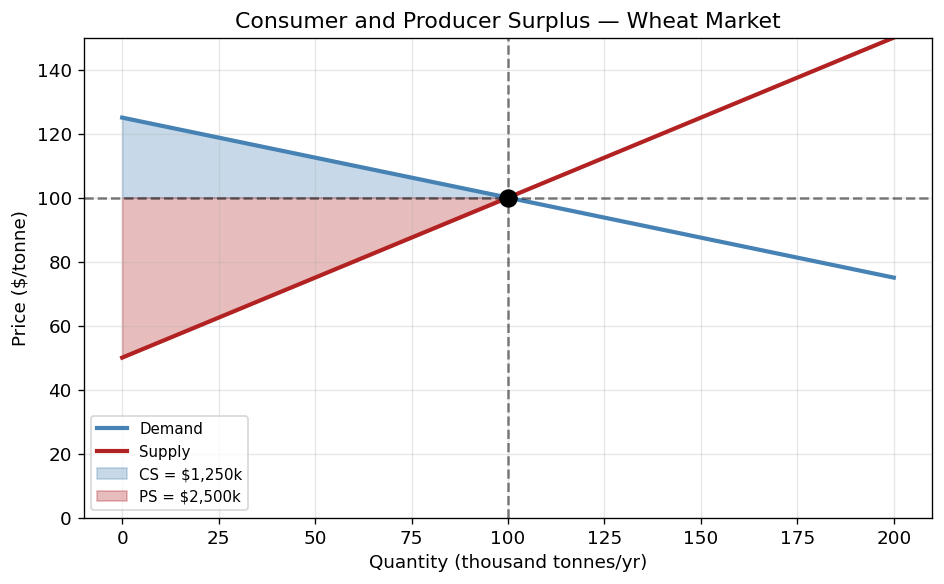

In [4]:
# B.1 — Shade surplus areas
Q_vals = np.linspace(0, Q_eq, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Demand and supply curves
ax.plot(np.linspace(0, 200, 300), demand_P(np.linspace(0, 200, 300)), "steelblue", lw=2.5, label="Demand")
ax.plot(np.linspace(0, 200, 300), supply_P(np.linspace(0, 200, 300)), "firebrick", lw=2.5, label="Supply")

# Shade CS (above P*, below demand curve)
ax.fill_between(Q_vals, demand_P(Q_vals), P_eq, alpha=0.3, color="steelblue", label=f"CS = $1,250k")
# Shade PS (below P*, above supply curve)
ax.fill_between(Q_vals, P_eq, supply_P(Q_vals), alpha=0.3, color="firebrick", label=f"PS = $2,500k")

ax.axhline(P_eq, color="k", ls="--", alpha=0.5)
ax.axvline(Q_eq, color="k", ls="--", alpha=0.5)
ax.plot(Q_eq, P_eq, "ko", ms=10, zorder=5)
ax.set_xlabel("Quantity (thousand tonnes/yr)")
ax.set_ylabel("Price ($/tonne)")
ax.set_title("Consumer and Producer Surplus — Wheat Market")
ax.set_ylim(0, 150)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part C: Surplus via Integration (~20 min)

$$CS = \int_0^{Q^*} D(Q)\,dQ - P^* \cdot Q^*$$

$$PS = P^* \cdot Q^* - \int_0^{Q^*} S(Q)\,dQ$$

In [5]:
# C.1 — CS and PS by numerical integration
try:
    from numpy import trapezoid  # NumPy >= 2.0
except ImportError:
    from numpy import trapz as trapezoid  # NumPy < 2.0

Q_fine = np.linspace(0, Q_eq, 10000)

area_under_demand = trapezoid(demand_P(Q_fine), Q_fine)
area_under_supply = trapezoid(supply_P(Q_fine), Q_fine)
price_times_qty   = P_eq * Q_eq

CS = area_under_demand - price_times_qty
PS = price_times_qty   - area_under_supply

print(f"Area under demand curve: {area_under_demand:,.1f}")
print(f"Area under supply curve: {area_under_supply:,.1f}")
print(f"P* × Q* = {price_times_qty:,.1f}")
print(f"\nConsumer Surplus (CS): ${CS:,.1f} thousand")
print(f"Producer Surplus (PS): ${PS:,.1f} thousand")
print(f"Total Surplus:         ${CS + PS:,.1f} thousand")

Area under demand curve: 11,250.0
Area under supply curve: 7,500.0
P* × Q* = 10,000.0

Consumer Surplus (CS): $1,250.0 thousand
Producer Surplus (PS): $2,500.0 thousand
Total Surplus:         $3,750.0 thousand


Analytic check (triangles).

In [6]:
# C.2 — Analytic check (triangles)
CS_analytic = 0.5 * Q_eq * (demand_P(0) - P_eq)
PS_analytic = 0.5 * Q_eq * (P_eq - supply_P(0))
print(f"CS (triangle formula): ${CS_analytic:,.1f}k")
print(f"PS (triangle formula): ${PS_analytic:,.1f}k")
print(f"Numerical matches analytic? CS: {abs(CS - CS_analytic) < 1}, PS: {abs(PS - PS_analytic) < 1}")

CS (triangle formula): $1,250.0k
PS (triangle formula): $2,500.0k
Numerical matches analytic? CS: True, PS: True


---
## Part D: Symbolic Integration with SymPy (~10 min)

Part C.1 used `numpy.trapz` to *numerically approximate* the area under the demand and supply curves. Python's **SymPy** library can instead find the **exact** area algebraically — the same **symbolic computation** idea as `sp.diff()` in Weeks 4–5 and `sp.integrate()` in Week 6. This is the standard tool you'll use for integration in Python throughout the rest of the unit.

Run the cell below to compute CS and PS using symbolic definite integration, and compare to your Part C.1/C.2 results.

In [7]:
# D.1 — CS and PS by symbolic integration
import sympy as sp

Q_sym = sp.symbols('Q', nonnegative=True)
demand_expr = (500 - Q_sym) / 4
supply_expr = (Q_sym + 100) / 2

# Symbolic definite integrals — the exact area under each curve from 0 to Q*
area_under_demand_sym = sp.integrate(demand_expr, (Q_sym, 0, Q_eq))
area_under_supply_sym = sp.integrate(supply_expr, (Q_sym, 0, Q_eq))

CS_sym = area_under_demand_sym - P_eq * Q_eq
PS_sym = P_eq * Q_eq - area_under_supply_sym

print(f"Integral from 0 to Q* of demand dQ = {area_under_demand_sym}")
print(f"Integral from 0 to Q* of supply dQ = {area_under_supply_sym}")
print(f"\nCS (symbolic integration) = ${float(CS_sym):,.1f}k   ← compare to Part C.1/C.2")
print(f"PS (symbolic integration) = ${float(PS_sym):,.1f}k   ← compare to Part C.1/C.2")

Integral from 0 to Q* of demand dQ = 11250.0000000000
Integral from 0 to Q* of supply dQ = 7500.00000000000

CS (symbolic integration) = $1,250.0k   ← compare to Part C.1/C.2
PS (symbolic integration) = $2,500.0k   ← compare to Part C.1/C.2


**Why this matters:** `sp.integrate()` finds the **exact** area under a curve algebraically, rather than approximating it numerically the way `numpy.trapz` does. Here demand and supply are both *straight lines*, so `trapz` was already exact (a straight-line segment has no curvature, so the trapezoid rule has zero error) — that's why C.1 and D.1 give identical answers. For a *curved* function — like the exponential sequestration rate in Week 6 — `trapz` only gives an approximation, and `sp.integrate()` is the only way to get the exact value.

✏️ **Group Discussion:**

1. Which group — buyers or sellers — benefits more from this wheat market? What does the ratio PS/CS tell you?
2. What would happen to CS and PS if the government imposed a price floor of $120/tonne?
3. Why is total surplus maximised at the competitive equilibrium?

```
DISCUSSION:
1. Producers are the better off group. Producers are making exactly twice as much surplus as the consumers. 2500/1250 = 2

2. If the government imposed a price floor of 120/tonne then both CS and PS would decrease. With the decreased demand becuause of higher prices, this increase in price doesn't make up for the loss of sales.

3. There is an equal amount of wheat being produced to what is being sold, so both consumers and producers are mutally benefiting at this price and tonneage.
```